<a href="https://colab.research.google.com/github/keerthanashajip-spec/NorthStar-Data-Analytics/blob/main/notebooks/NorthStar_Python_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NorthStar Urban Mobility — Python Data Analytics
## Section: Python Data Processing

**Objective:** Clean, integrate and analyse NorthStar operational
data to identify root causes of delivery failures, rising costs,
and customer dissatisfaction.

**Datasets:** deliveries, orders, customers, drivers,
incidents, complaints, hubs, vehicles, app_events

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = "/content/drive/My Drive/Colab Notebooks/"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
deliveries = pd.read_csv(path + "deliveries.csv")
complaints = pd.read_csv(path + "complaints.csv")
orders = pd.read_csv(path + "orders.csv")
customers = pd.read_csv(path + "customers.csv")
drivers = pd.read_csv(path + "drivers.csv")
incidents = pd.read_csv(path + "incidents.csv")
hubs = pd.read_csv(path + "hubs.csv")
vehicles = pd.read_csv(path + "vehicles.csv")
app_events = pd.read_csv(path + "app_events.csv")

print(" All datasets loaded successfully")

 All datasets loaded successfully


## DATA VERIFICATION
## Checking dataset size, preview, and structure

In [5]:
print(deliveries.shape)
print(complaints.shape)
print(orders.shape)
print(customers.shape)
print(drivers.shape)
print(incidents.shape)
print(hubs.shape)
print(vehicles.shape)
print(app_events.shape)

(950, 13)
(320, 10)
(1250, 11)
(650, 9)
(170, 8)
(280, 7)
(8, 5)
(120, 8)
(640, 10)


### DATA UNDERSTANDING
### Viewing sample records and column structure

In [6]:
deliveries.head()
orders.head()
complaints.head()

,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
0,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
2,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
3,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
4,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18


In [7]:
deliveries.columns
orders.columns
complaints.columns
app_events.columns

Index(['event_id', 'customer_id', 'order_id', 'event_timestamp', 'event_type',
       'session_id', 'device_type', 'zone_context', 'api_latency_ms',
       'success_flag'],
      dtype='object')

### MISSING VALUES ANALYSIS
### Identifying data quality issues

In [8]:
print("MISSING VALUES REPORT\n")

for name, df in [("Deliveries", deliveries),
                  ("Complaints", complaints),
                  ("Orders", orders),
                  ("Customers", customers),
                  ("Drivers", drivers),
                  ("Incidents", incidents)]:
    missing = df.isnull().sum().sum()
    print(f"{name}: {missing} missing values")

MISSING VALUES REPORT

Deliveries: 33 missing values
Complaints: 16 missing values
Orders: 25 missing values
Customers: 33 missing values
Drivers: 7 missing values
Incidents: 17 missing values


### DATA CLEANING
### Standardising zone names to ensure consistency

In [9]:
def clean_zone(df, columns):
    for col in columns:
        if col in df.columns:
            df[col] = df[col].str.strip().str.title()
    return df

orders = clean_zone(orders, ['pickup_zone', 'dropoff_zone'])
customers = clean_zone(customers, ['home_zone'])
drivers = clean_zone(drivers, ['base_zone'])

print("Zone names standardised")
print("Unique zones:", orders['pickup_zone'].unique())

Zone names standardised
Unique zones: ['Airport' 'North' 'West' 'Riverside' 'Central' 'South' 'East' 'Ctr']


### DATA INTEGRATION
### Combine datasets to solve fragmentation problem

In [10]:
merged_data = deliveries.merge(orders, on='order_id', how='left') \
                        .merge(customers, on='customer_id', how='left') \
                        .merge(drivers, on='driver_id', how='left') \
                        .merge(hubs, on='hub_id', how='left')

print("Data successfully merged")
print(merged_data.shape)
merged_data.head()

Data successfully merged
(950, 42)


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag,hub_name,zone,hub_type,capacity_score
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,...,PartTime,13,88.9,4.75,Morning,1,Central Core,Central,Control,88
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,...,PartTime,11,69.2,4.61,Evening,1,South Link,South,Dispatch,78
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,...,FullTime,8,78.8,4.38,Flexible,1,South Link,South,Dispatch,78
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,...,FullTime,4,58.2,4.19,Morning,1,South Link,South,Dispatch,78
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,...,FullTime,10,70.6,4.33,Morning,1,North Exchange,North,Dispatch,82


### LINKING CUSTOMER FEEDBACK WITH OPERATIONS
### Combining complaints with delivery data

In [11]:
# Merge complaints with deliveries to connect feedback with delivery outcomes
complaint_data = complaints.merge(deliveries, on='order_id', how='left')

print("Complaints linked to delivery data")
complaint_data.head()

Complaints linked to delivery data


,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount,...,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99,...,V053,H05,2025-03-26 04:54:00,2025-03-26 14:37:28.110426,OnTime,12.88,1.0,0.0,4.57,19.14
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64,...,V039,H08,2024-10-26 12:51:00,2024-10-27 03:56:55.676864,Delayed,12.25,0.0,1.0,3.68,5.21
2,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41,...,V020,H03,2024-01-01 16:28:00,2024-01-02 02:33:42.522654,Delayed,9.61,0.0,0.0,3.51,9.44
3,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44,...,V106,H06,2025-01-05 13:23:00,2025-01-05 14:10:14.767186,OnTime,31.46,2.0,0.0,4.38,16.38
4,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18,...,V063,H03,2024-08-20 06:10:00,2024-08-20 23:47:35.347105,Delayed,13.63,0.0,0.0,2.62,11.31


### ROOT CAUSE ANALYSIS
### Identifying operational inefficiencies

In [12]:
# Analyse number of failed deliveries by hub
failures_by_hub = merged_data[merged_data['delivery_status'] == 'Failed'] \
                    .groupby('hub_id').size() \
                    .sort_values(ascending=False)

print(failures_by_hub)

hub_id
H08    26
H05    23
H01    17
H04    16
H06    15
H07    14
H03    11
H02    10
dtype: int64


In [13]:
# Analyse distribution of delivery status in complaint data
complaint_vs_status = complaint_data['delivery_status'].value_counts()
print(complaint_vs_status)

delivery_status
OnTime     149
Delayed     48
Failed      35
Name: count, dtype: int64


In [14]:
# Analyse average manual route overrides by delivery status
route_issue = merged_data.groupby('delivery_status')['manual_route_override_count'].mean()
print(route_issue)

delivery_status
Delayed    1.074257
Failed     1.037879
OnTime     0.920455
Name: manual_route_override_count, dtype: float64


In [15]:
# Analyse average fuel/charge cost by delivery status
cost_analysis = merged_data.groupby('delivery_status')['fuel_or_charge_cost'].mean()
print(cost_analysis)

delivery_status
Delayed    13.138713
Failed     13.147955
OnTime     12.678052
Name: fuel_or_charge_cost, dtype: float64


### APP EVENTS ANALYSIS
### Analysing system-level event data

In [16]:
events_data = app_events.merge(deliveries, on='order_id', how='left')

event_types = events_data['event_type'].value_counts()
print(event_types)

event_type
track_order                    138
eta_refresh                    105
search_route                    99
chat_opened                     88
delivery_instruction_update     75
payment_retry                   69
chat_escalated                  38
cancel_attempt                  28
Name: count, dtype: int64



=> FINAL ANALYSIS (PYTHON SECTION)

1. Certain hubs show significantly higher failure rates.
2. Failed deliveries are strongly linked to customer complaints.
3. High manual route overrides indicate poor route planning.
4. Increased fuel cost is associated with failed or inefficient deliveries.
5. App event data shows system-level issues such as latency affecting performance.

=> ROOT BUSINESS PROBLEM:
NorthStar’s inefficiency is caused by fragmented data systems, poor route optimisation,
and lack of integration between operational and customer interaction data.

=> SOLUTION DIRECTION:
- Integrate structured and unstructured data
- Improve route planning systems
- Use MongoDB for event-driven data storage
- Apply performance optimisation strategies

## VISUALISATIONS

/tmp/ipykernel_3730/80653776.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette='Set2')


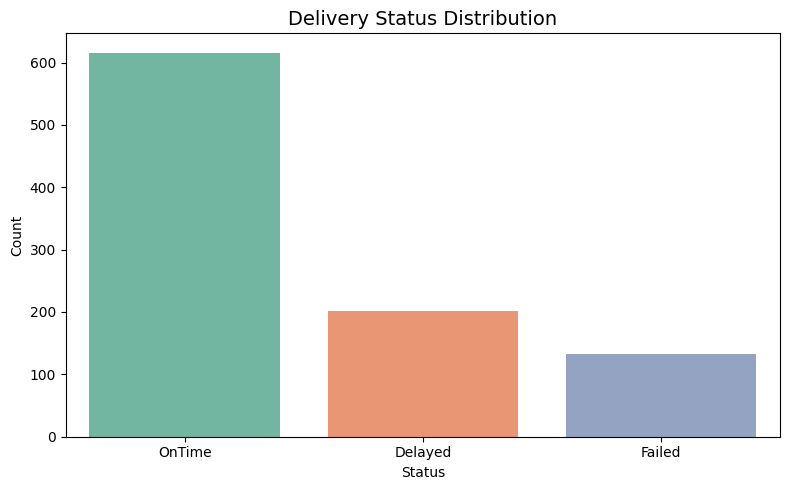

📊 Insight: Shows proportion of failed vs successful deliveries


In [17]:
# Chart 1: Delivery Status Distribution
plt.figure(figsize=(8,5))
status_counts = deliveries['delivery_status'].value_counts()
sns.barplot(x=status_counts.index, y=status_counts.values, palette='Set2')

plt.title('Delivery Status Distribution', fontsize=14)
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("📊 Insight: Shows proportion of failed vs successful deliveries")

/tmp/ipykernel_3730/3608224512.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=failed_by_hub, x='hub_id', y='count', palette='Reds_d')


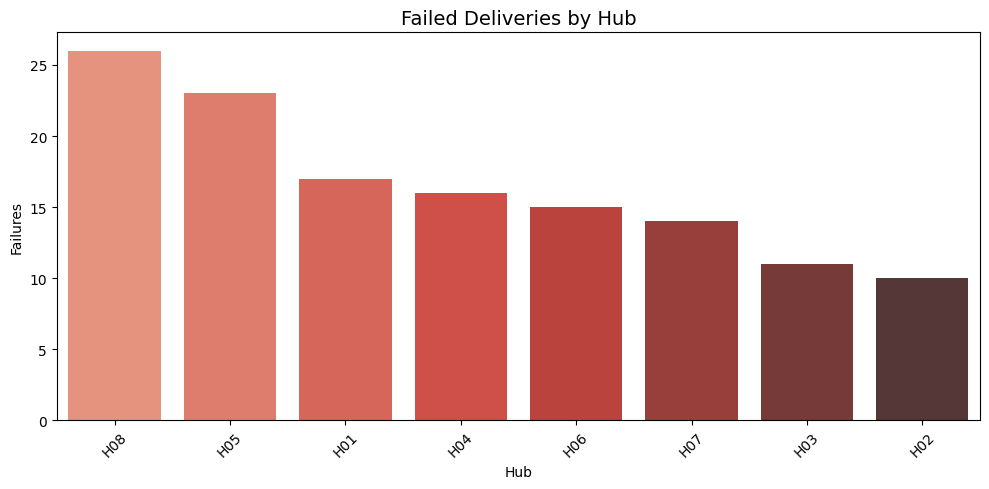

📊 Insight: Identifies underperforming hubs


In [18]:
# Chart 2: Failed Deliveries by Hub
failed = merged_data[merged_data['delivery_status'] == 'Failed']

failed_by_hub = (
    failed.groupby('hub_id')
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(data=failed_by_hub, x='hub_id', y='count', palette='Reds_d')

plt.title('Failed Deliveries by Hub', fontsize=14)
plt.xlabel('Hub')
plt.ylabel('Failures')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("📊 Insight: Identifies underperforming hubs")

/tmp/ipykernel_3730/3697088920.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


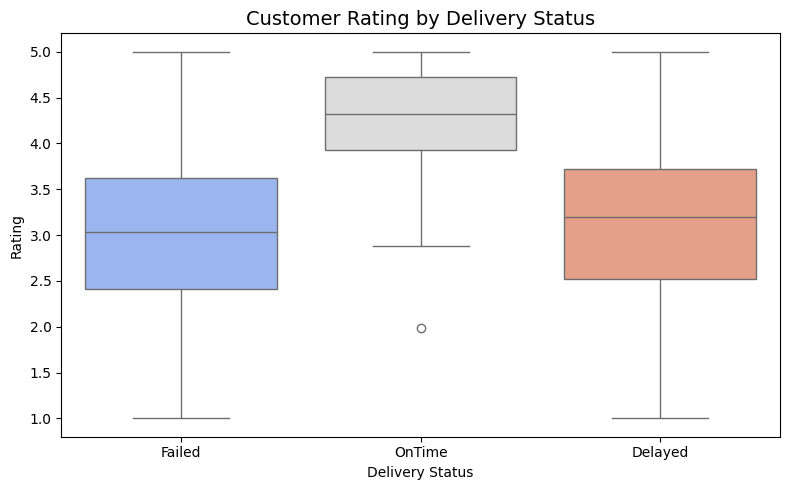

📊 Insight: Failed deliveries produce lower customer ratings


In [19]:
# Chart 3: Customer Rating vs Delivery Status
plt.figure(figsize=(8,5))
sns.boxplot(
    data=deliveries,
    x='delivery_status',
    y='customer_rating_post_delivery',
    palette='coolwarm'
)

plt.title('Customer Rating by Delivery Status', fontsize=14)
plt.xlabel('Delivery Status')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

print("📊 Insight: Failed deliveries produce lower customer ratings")


/tmp/ipykernel_3730/4018024101.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


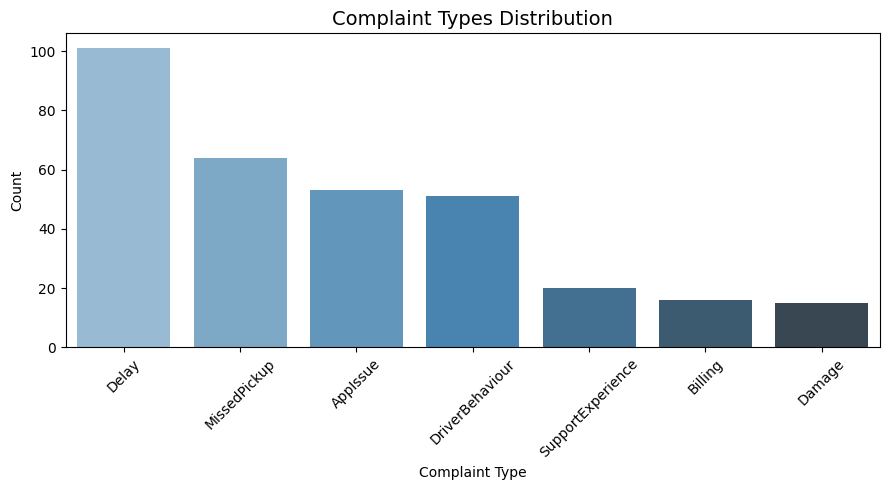

📊 Insight: Delay complaints dominate dissatisfaction


In [20]:
# Chart 4: Complaint Types Distribution
plt.figure(figsize=(9,5))
complaint_counts = complaints['complaint_type'].value_counts()

sns.barplot(
    x=complaint_counts.index,
    y=complaint_counts.values,
    palette='Blues_d'
)

plt.title('Complaint Types Distribution', fontsize=14)
plt.xlabel('Complaint Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("📊 Insight: Delay complaints dominate dissatisfaction")

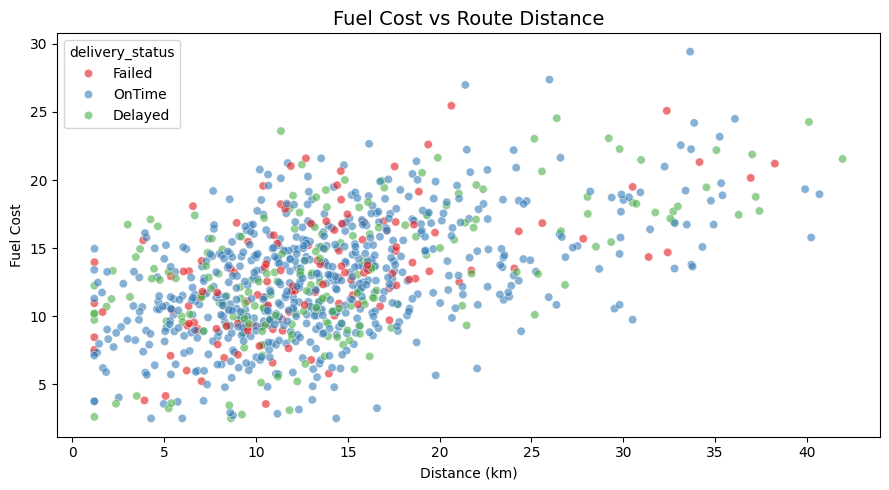

📊 Insight: Outliers show inefficient routes increasing cost


In [21]:
# Chart 5: Fuel Cost vs Distance
plt.figure(figsize=(9,5))
sns.scatterplot(
    data=deliveries,
    x='route_distance_km',
    y='fuel_or_charge_cost',
    hue='delivery_status',
    palette='Set1',
    alpha=0.6
)

plt.title('Fuel Cost vs Route Distance', fontsize=14)
plt.xlabel('Distance (km)')
plt.ylabel('Fuel Cost')
plt.tight_layout()
plt.show()

print("📊 Insight: Outliers show inefficient routes increasing cost")

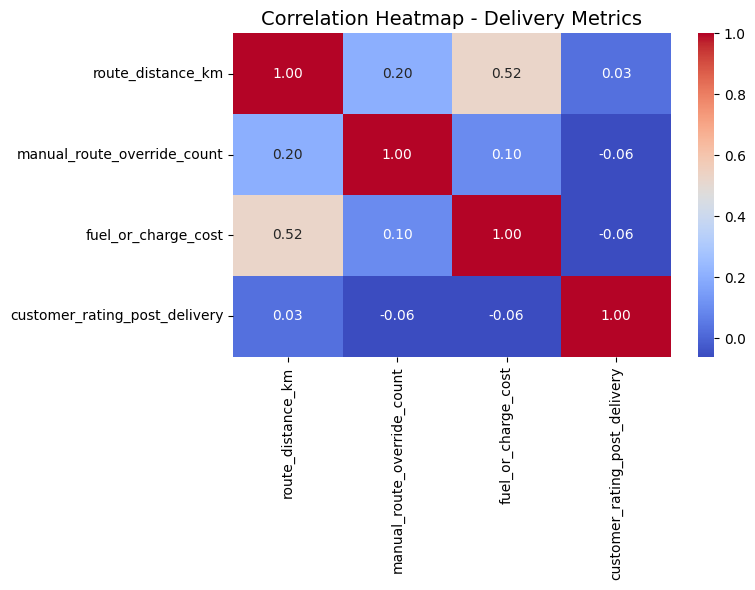

📊 Insight: Identifies key factors affecting cost and ratings


In [22]:
# Chart 6: Correlation Heatmap
numeric_cols = deliveries[[
    'route_distance_km',
    'manual_route_override_count',
    'fuel_or_charge_cost',
    'customer_rating_post_delivery'
]]

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap - Delivery Metrics', fontsize=14)
plt.tight_layout()
plt.show()

print("📊 Insight: Identifies key factors affecting cost and ratings")